<a href="https://colab.research.google.com/github/koechjared/git-journey/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AUC Score: 0.9999984948357523

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    170333
           1       1.00      1.00      1.00     29667

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000


Top prioritized accounts:
         dpd  num_missed_payments  last_payment_days_ago  avg_monthly_inflow  \
280496  1064                    1                   1356        56354.108232   
235914  1021                    0                     24        67358.973940   
246601  1855                    0                   1629        56203.553603   
782491  1017                    3                   1159        61897.706315   
980086  1178                    1                    318        38081.459997   
806023   703                    0                    306        56969.487683   
619543  1854                   

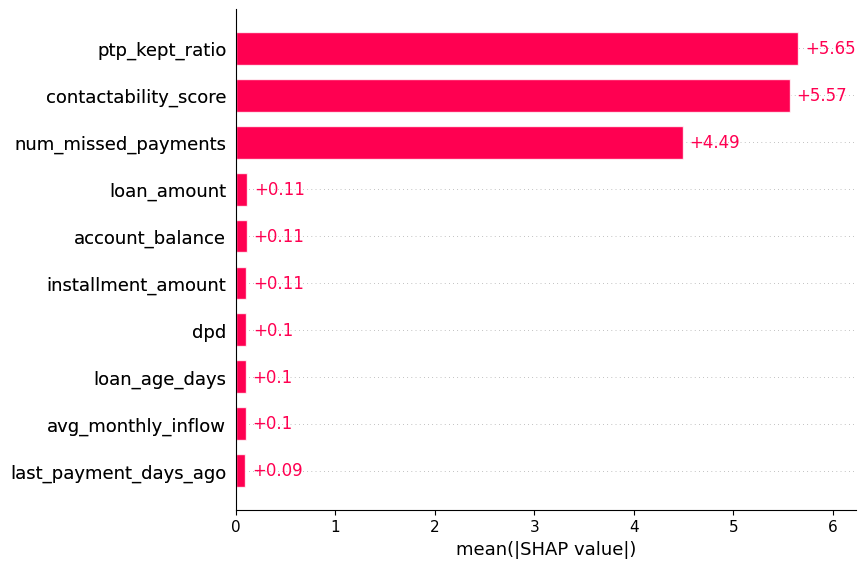

In [3]:
'''Top drivers are usually:

DPD
Time since last payment
PTP kept ratio
Cash flow indicators
Contactability'''

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import shap


# CREATE SYNTHETIC DATASET

np.random.seed(42)
n = 1000000

data = pd.DataFrame({
    "dpd": np.random.randint(121, 2000, n),  # Days past due
    "num_missed_payments": np.random.randint(0, 10, n),
    "last_payment_days_ago": np.random.randint(1, 2000, n),
    "avg_monthly_inflow": np.random.normal(50000, 20000, n),
    "account_balance": np.random.normal(10000, 500000, n),
    "ptp_kept_ratio": np.random.uniform(0, 1, n),
    "contactability_score": np.random.uniform(0, 1, n),
    "loan_amount": np.random.normal(10000, 700000, n),
    "installment_amount": np.random.normal(10000, 4000, n),
    "loan_age_days": np.random.randint(30, 720, n)
})

# Simulated target (Propensity to Pay within 30 days)
# Logic: better behavior → higher probability
data["target_paid_30d"] = (
    (data["dpd"] < 30).astype(int) +
    (data["ptp_kept_ratio"] > 0.5).astype(int) +
    (data["contactability_score"] > 0.5).astype(int) -
    (data["num_missed_payments"] > 5).astype(int)
)

# Convert to binary
data["target_paid_30d"] = (data["target_paid_30d"] > 1).astype(int)


# TRAIN_TEST SPLIT

X = data.drop(columns=["target_paid_30d"])
y = data["target_paid_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# TRAIN XGBOOST MODEL

'''Build 200 moderately complex trees, learn gradually,
introduce randomness to avoid overfitting,
and optimize for accurate probability predictions of repayment.'''
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# MODEL EVALUATION

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# SCORE & PRIORITIZE ACCOUNTS

X_test_copy = X_test.copy()
X_test_copy["ptp_score"] = y_pred_proba

# Create priority bands
def assign_priority(score):
    if score >= 0.7:
        return "High"
    elif score >= 0.4:
        return "Medium"
    else:
        return "Low"

X_test_copy["priority"] = X_test_copy["ptp_score"].apply(assign_priority)

# View top accounts to prioritize
prioritized_accounts = X_test_copy.sort_values(by="ptp_score", ascending=False)

print("\nTop prioritized accounts:")
print(prioritized_accounts.head(10))

# Explainability
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)